# Looking at t = 10 000 cuvre
for $N = 2^{16}$

## Imports

In [33]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from math import log, e, pi, sqrt
from statistics import NormalDist
from scipy.stats import norm

## Constants

In [47]:
N = 2 ** 16
p = 1 - e ** (-2)
alpha = 0.95
t = 10000

## Import in data

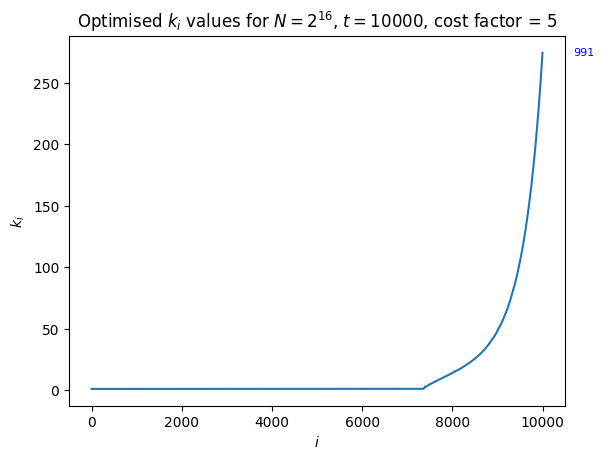

In [53]:
with open('N_16_t_10000_optimised_kjs.pkl', 'rb') as f:
    result = pickle.load(f)

kjs, m_0, final_cost, m_values = result

# plot kjs
plt.plot(kjs)
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values[-1]
y = kjs[-1]

plt.annotate(round(mt),
             xy = (len(kjs)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = 'blue',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{16}$, $t=10000$, cost factor = 5')
plt.show()


## How many points do we get if we have a vanilla table?

In [14]:
## use formula to calculate vanilla m_t for t=10000

# calculate m_0 
def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def calculate_vanilla_mt_formula(N, t, alpha):
    m_0 = calculate_m0(N, t, alpha)
    mt = (2 * N) / (t + ((2 * N)/ m_0))
    return mt

# 12 points lol
print("Vanilla m_t for t=10000:", calculate_vanilla_mt_formula(N, t, alpha))

Vanilla m_t for t=10000: 12.45171548284517


In [37]:
## use approximation to estimate vanilla m_t for t=10000
def get_mean(N, m):
    return N * (1 - (1 - 1/N) ** m)

def get_variance(N, m):
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    return N * ((N - 1) * E2 + E1 - N * E1 ** 2)

def approximate_next_col(N, m, k=1):
    mean = get_mean(N, m)
    variance = get_variance(N, m)

    return mean + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sqrt(variance)


def approximate_vanilla_mt(N, t, alpha):
    m_0 = calculate_m0(N, t, alpha)
    m = m_0
    for i in range(t):
        m = approximate_next_col(N, m)
    return m

# 13 - pretty close yeah
print("Approximate vanilla m_t for t=10000:", approximate_vanilla_mt(N, t, alpha))

Approximate vanilla m_t for t=10000: 12.955884404320386


In [39]:
def approximate_cherry(N, t, alpha, kjs):
    m_0 = calculate_m0(N, t, alpha)
    m = m_0
    m_val = [m_0]
    for i in range(t):
        m = approximate_next_col(N, m, k=kjs[i])
        m_val.append(m)
    return m, m_val

In [ ]:
## sampling method

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    return sqrt(N * (((N - 1) * E2) + E1 - (N * (E1 ** 2))))

# Cherry Table Simulation - only returns number of endpoints
def cherry_table_simulation(N, t, K, startpoints_len):

    m = startpoints_len
    m_val = [m]

    # for each column
    for i in range(len(K)):
        # get the mean (loc)
        # get the standard deviation (scale)
        mean = get_mean(N, m)
        std = get_std(N, m)
        # get distribution of the current column
        column_dist = norm(loc=mean, scale=std)
        # for the next column, we want to sample K times and use the maximum
        samples = column_dist.rvs(size=round(K[i]))
        # set m to be the maximum of these samples
        m = max(samples)
        m_val.append(m)


    return m, m_val


cherry_mts = []
cherry_m =[]

cherry_m_0 = round(calculate_m0(N, t, alpha))    # our starting m_0

# run 100 simulations
for _ in range(1):
    mt, m_val = cherry_table_simulation(N, t, kjs, cherry_m_0)
    cherry_mts.append(mt)
    cherry_m.append(m_val)

print("Mean of cherry table simulation m_t:", np.mean(cherry_mts))
    

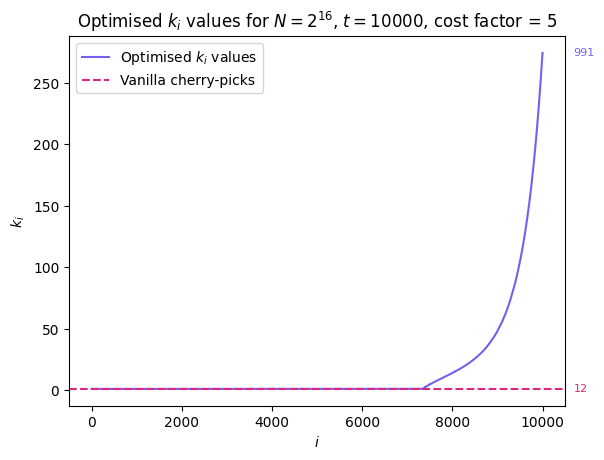

In [22]:
## redo graph but plot vanilla m_t as a horizontal line

# plot kjs
plt.plot(kjs, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values[-1]
y = kjs[-1]

plt.annotate(round(mt),
             xy = (len(kjs)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (len(kjs)+500, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{16}$, $t=10000$, cost factor = 5')
plt.legend()
plt.show()

## At what point does cherry-picking start

This is a dud - approximation got weird so then m values start INCREASING?? after single cherry-picks 

In [ ]:
# find index in kjs element is above 1 - column 7382
for i, k in enumerate(kjs):
    if k > 2:
        print("Index where k_i exceeds 1:", i)
        break

Index where k_i exceeds 1: 7381


In [26]:
calculate_m0(N, t, alpha)

248.98700259947987

## Figure out new k-curve

### Try the above k_curve and see if the approximation works at 2**40
make sure to sanity check m_values and make sure they are never increasing 

In [54]:
N = 2 ** 40

from decimal import Decimal, getcontext

# Set precision to 50 decimal places to prevent catastrophic cancellation
getcontext().prec = 50

def get_mean(N, m):
    # Convert to Decimal for high-precision arithmetic
    N_dec = Decimal(N)
    m_dec = Decimal(m)
    return N_dec * (1 - (1 - 1/N_dec) ** m_dec)

def get_variance(N, m):
    N_dec = Decimal(N)
    m_dec = Decimal(m)
    
    E1 = (1 - 1 / N_dec) ** m_dec
    E2 = (1 - 2 / N_dec) ** m_dec

    # The precision here prevents the result from flipping to a negative float
    variance = N_dec * ((N_dec - 1) * E2 + E1 - N_dec * (E1 ** 2))
    
    # Return 0 if variance is effectively zero but technically negative due to precision
    return max(Decimal(0), variance)

def approximate_next_col(N, m, k=1):
    mean = get_mean(N, m)
    variance = get_variance(N, m)
    
    # Calculate the standard deviation using Decimal's sqrt method
    std_dev = variance.sqrt()

    # NormalDist and pi are standard floats; we convert back to float for the final step
    # as inv_cdf expects a float input.
    z_score = NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1))
    
    return float(mean) + z_score * float(std_dev)

def calculate_m0(N, t, alpha):
    N_dec = Decimal(N)
    t_dec = Decimal(t)
    alpha_dec = Decimal(alpha)
    mttarget = (2 * N_dec) / (t_dec + 2)
    return (alpha_dec * mttarget) / (1 - alpha_dec)

def approximate_cherry(N, t, alpha, kjs):
    m_0 = calculate_m0(N, t, alpha)
    m = m_0
    m_val = [float(m_0)] # Store as floats for easier printing/plotting
    
    for i in range(t):
        # We pass m as the current Decimal value to maintain precision across iterations
        m = approximate_next_col(N, m, k=kjs[i])
        m_val.append(m)
        
    return m, m_val

# --- Execution ---
N = 2 ** 40

print(calculate_m0(N, t, alpha))

try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

mt, m_val = approximate_cherry(N, t, alpha, kjs)
print("Approximate cherry m_t for N = 2**40, t=10000:", mt)

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_val)-1):
    if m_val[i] < m_val[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

for item in m_val:
    print(item)


4177308723.8040352866926614677099274614596616787716
Success! Approximate cherry m_t for N = 2**40: 209563424.1298
Approximate cherry m_t for N = 2**40, t=10000: 209563424.12980583
4177308723.804035
4169383464.1223726
4161488228.826054
4153622847.5835133
4145787151.3493648
4137980972.352286
4130204144.0830364
4122456501.2826104
4114737879.930523
4107048117.2332273
4099387051.6126637
4091754522.694934
4084150371.2991033
4076574439.426128
4069026570.2479043
4061506608.09644
4054014398.453145
4046549787.9382434
4039112624.3002973
4031702756.405851
4024320034.2291846
4016964308.8421845
4009635432.404322
4002333258.1527424
3995057640.392461
3987808434.486668
3980585496.8471394
3973388684.924747
3966217857.200078
3959072873.1741514
3951953593.3592362
3944859879.269769
3937791593.4133687
3930748599.2819467
3923730761.342915
3916737945.030487
3909770016.7370696
3902826843.80475
3895908294.5168715
3889014238.089699
3882144544.6641726
3875299085.2977505
3868477731.956334
3861680357.506283
3854906

In [51]:
calculate_vanilla_mt_formula(N, t, alpha)

Decimal('208905120.22623772785524099739452800978710411044614')

In [52]:
approximate_vanilla_mt(N, t, alpha)

208885303.6881098

208865436


In [65]:
N = 2**40
t=10000
alpha=0.95

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def calculate_vanilla_mt_formula(N, t, alpha):
    mt_max = (2*N)/(t + 2)
    return(round(alpha * mt_max))

print(calculate_m0(N, t, alpha))
print(calculate_vanilla_mt_formula(N, t, alpha))

4177308723.804035
208865436


In [62]:
calculate_vanilla_mt_formula(N, 5, alpha)

298438870396